In [1]:
import os
import sys

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(PROJECT_ROOT)

d:\Property Intelligence Platform


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from src.data.ingestion import load_data

df = load_data("../data/feature_engineered/gurgaon_properties_cleaned_v2.csv")


Dataset loaded successfully.
Rows: 3803
Columns: 23


In [4]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,sare crescent parc royal greens phase 1,sector 92,0.85,4877.0,1743.0,Built Up area: 1743 (161.93 sq.m.),4,4,3,...,NaN,1743.0,NaN,0,0,0,0,0,0,0
1,flat,sare green parc phase 3,sector 92,1.08,5150.0,2097.0,Super Built up area 2090(194.17 sq.m.),4,4,2,...,2090.0,NaN,NaN,0,1,0,0,0,0,107
2,house,unitech uniworld resorts,sector 33,8.00,11428.0,7000.0,Plot area 7000(650.32 sq.m.),4,4,3+,...,NaN,7000.0,NaN,1,1,1,1,0,0,77
3,flat,ireo the corridors,sector 67a,1.60,9264.0,1727.0,Super Built up area 1727(160.44 sq.m.)Carpet a...,3,3,2,...,1727.0,NaN,1017.0,0,0,1,0,0,1,142
4,house,rwa sector 46,sector 46,4.50,24390.0,1845.0,Plot area 204(170.57 sq.m.)Built Up area: 206 ...,6,6,3+,...,NaN,206.0,205.0,0,0,1,0,0,1,80


In [5]:
df.shape

(3803, 23)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3803 entries, 0 to 3802
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3803 non-null   object 
 1   society              3802 non-null   object 
 2   sector               3803 non-null   object 
 3   price                3785 non-null   float64
 4   price_per_sqft       3785 non-null   float64
 5   area                 3785 non-null   float64
 6   areaWithType         3803 non-null   object 
 7   bedRoom              3803 non-null   int64  
 8   bathroom             3803 non-null   int64  
 9   balcony              3803 non-null   object 
 10  floorNum             3784 non-null   float64
 11  facing               2698 non-null   object 
 12  agePossession        3803 non-null   object 
 13  super_built_up_area  1915 non-null   float64
 14  built_up_area        1733 non-null   float64
 15  carpet_area          1944 non-null   f

In [7]:
df.duplicated().sum()

np.int64(126)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,sare crescent parc royal greens phase 1,sector 92,0.85,4877.0,1743.0,Built Up area: 1743 (161.93 sq.m.),4,4,3,...,NaN,1743.0,NaN,0,0,0,0,0,0,0
1,flat,sare green parc phase 3,sector 92,1.08,5150.0,2097.0,Super Built up area 2090(194.17 sq.m.),4,4,2,...,2090.0,NaN,NaN,0,1,0,0,0,0,107
2,house,unitech uniworld resorts,sector 33,8.00,11428.0,7000.0,Plot area 7000(650.32 sq.m.),4,4,3+,...,NaN,7000.0,NaN,1,1,1,1,0,0,77
3,flat,ireo the corridors,sector 67a,1.60,9264.0,1727.0,Super Built up area 1727(160.44 sq.m.)Carpet a...,3,3,2,...,1727.0,NaN,1017.0,0,0,1,0,0,1,142
4,house,rwa sector 46,sector 46,4.50,24390.0,1845.0,Plot area 204(170.57 sq.m.)Built Up area: 206 ...,6,6,3+,...,NaN,206.0,205.0,0,0,1,0,0,1,80


### property_type

In [10]:
summary = (
    df['property_type']
    .value_counts(dropna=False)
    .rename("Count")
    .to_frame()
)

summary["Percentage"] = (
    summary["Count"] / summary["Count"].sum() * 100
).round(2)

summary

,Count,Percentage
property_type,,
flat,2818,76.64
house,859,23.36


<Axes: xlabel='property_type'>

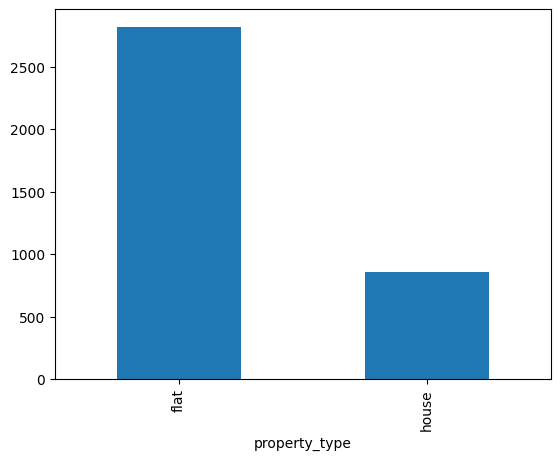

In [11]:
df['property_type'].value_counts().plot(kind='bar')

## Observation

- The dataset contains **3,677** properties, comprising **2,818 flats (76.64%)** and **859 houses (23.36%)**.
- **Flats are the predominant property type**, representing over three-quarters of all property listings in the dataset.
- The ratio of flats to houses is approximately **3.3 : 1**, indicating that apartment-style properties are significantly more common than independent houses.
- The distribution is **moderately imbalanced** toward flats. While this imbalance is not a concern for a regression problem, it should be considered when interpreting model performance across different property types.
- Since **property type** is expected to influence the selling price, further analysis should compare the price distributions of flats and houses using bivariate analysis (e.g., box plots or violin plots).

### society

In [12]:

df['society'].value_counts().shape

(676,)

In [13]:
df['society'].value_counts()

society
independent                             486
tulip violet                             75
ss the leaf                              73
shapoorji pallonji joyville gurugram     42
dlf new town heights                     42
                                       ... 
ashok vihar phase iii extension           1
vipul world floors                        1
huda floor                                1
meditech apartment                        1
uphaar homes                              1
Name: count, Length: 676, dtype: int64

In [14]:
df[df['society'] != 'independent']['society'].value_counts(normalize=True).cumsum().head(75)

society
tulip violet                            0.023511
ss the leaf                             0.046395
shapoorji pallonji joyville gurugram    0.059561
dlf new town heights                    0.072727
signature global park                   0.083699
                                          ...   
puri emerald bay                        0.490282
umang monsoon breeze                    0.494357
ramsons kshitij                         0.498433
ireo the corridors                      0.502194
unitech uniworld resorts                0.505956
Name: proportion, Length: 75, dtype: float64

In [15]:
society_counts = df['society'].value_counts()

# Frequency distribution for societies
frequency_bins = {
    "Very High (>100)": (society_counts > 100).sum(),
    "High (50-100)": ((society_counts >= 50) & (society_counts <= 100)).sum(),
    "Average (10-49)": ((society_counts >= 10) & (society_counts < 50)).sum(),
    "Low (2-9)": ((society_counts > 1) & (society_counts < 10)).sum(),
    "Very Low (1)": (society_counts == 1).sum()
}
frequency_bins

{'Very High (>100)': np.int64(1),
 'High (50-100)': np.int64(2),
 'Average (10-49)': np.int64(92),
 'Low (2-9)': np.int64(273),
 'Very Low (1)': np.int64(308)}

In [16]:
society_counts

society
independent                             486
tulip violet                             75
ss the leaf                              73
shapoorji pallonji joyville gurugram     42
dlf new town heights                     42
                                       ... 
ashok vihar phase iii extension           1
vipul world floors                        1
huda floor                                1
meditech apartment                        1
uphaar homes                              1
Name: count, Length: 676, dtype: int64

<Axes: xlabel='society'>

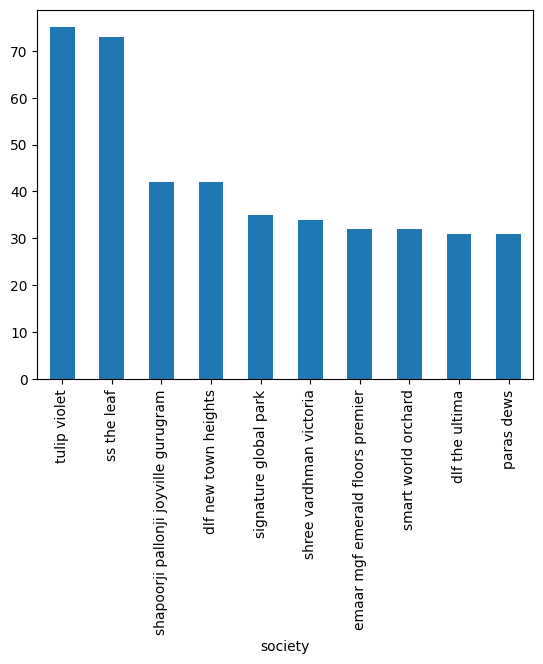

In [17]:
# top 10 socities
df[df['society'] != 'independent']['society'].value_counts().head(10).plot(kind='bar')

In [18]:
df['society'].isnull().sum()

np.int64(1)

In [19]:
df[df['society'].isnull()]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
424,flat,NaN,sector 78,0.6,3692.0,1625.0,Built Up area: 1625 (150.97 sq.m.),2,2,0,...,NaN,1625.0,NaN,0,0,0,0,0,0,0


## Observations

- Approximately **13%** of the properties are categorized as **independent properties**, while the remaining listings belong to residential societies.
- The dataset contains **675 unique societies**, indicating a diverse distribution of properties across multiple residential communities.
- The **top 75 societies** account for **approximately 50% of all property listings**, whereas the remaining **600 societies collectively contribute the other 50%**. This suggests that property listings are concentrated in a relatively small number of societies.
- Based on the number of listings per society:
  - **Very High (>100 listings):** Only **1 society** has more than **100** property listings.
  - **High (50–100 listings):** **2 societies** have between **50 and 100** listings.
  - **Average (10–49 listings):** **92 societies** fall within this range.
  - **Low (2–9 listings):** **273 societies** have between **2 and 9** listings.
  - **Very Low (1 listing):** **308 societies** have only a **single property listing**, indicating a long-tail distribution where many societies are represented by just one observation.
- The **society** feature contains **1 missing value**, which should be handled appropriately during the data preprocessing stage.

### sector

In [20]:
# unique sectors
df['sector'].value_counts().shape

(113,)

<Axes: xlabel='sector'>

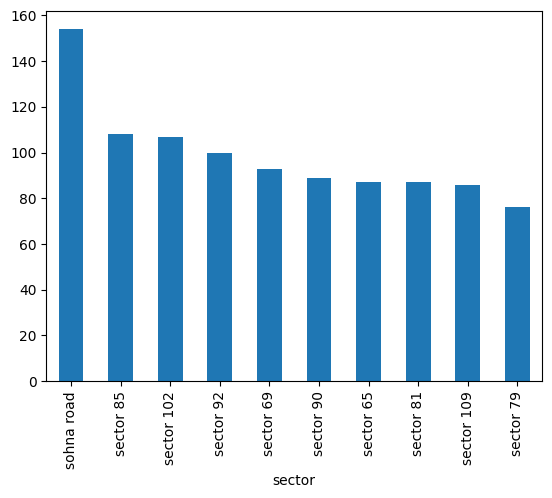

In [21]:
# top 10 sectors
df['sector'].value_counts().head(10).plot(kind='bar')

In [22]:
# Frequency distribution for sectors
sector_counts = df['sector'].value_counts()

sector_frequency_bins = {
    "Very High (>100)": (sector_counts > 100).sum(),
    "High (50-100)": ((sector_counts >= 50) & (sector_counts <= 100)).sum(),
    "Average (10-49)": ((sector_counts >= 10) & (sector_counts < 50)).sum(),
    "Low (2-9)": ((sector_counts > 1) & (sector_counts < 10)).sum(),
    "Very Low (1)": (sector_counts == 1).sum()
}

sector_frequency_bins

{'Very High (>100)': np.int64(3),
 'High (50-100)': np.int64(25),
 'Average (10-49)': np.int64(63),
 'Low (2-9)': np.int64(21),
 'Very Low (1)': np.int64(1)}

## Observations

- The dataset contains **104 unique sectors**, indicating a broad geographical distribution of property listings.
- Property listings are spread across sectors with varying frequencies, reflecting differences in market activity and housing availability.
- Based on the number of listings per sector:
  - **Very High (>100 listings):** **3 sectors** have more than **100** property listings, representing the most active real estate markets in the dataset.
  - **High (50–100 listings):** **25 sectors** contain between **50 and 100** listings.
  - **Average (10–49 listings):** The majority of sectors (**60**) fall within this range, indicating a balanced representation across most locations.
  - **Low (2–9 listings):** **16 sectors** have relatively few property listings.
  - **Very Low (1 listing):** **No sector** has only a single listing, suggesting that every sector is represented by at least two properties.
- Overall, the **sector** feature exhibits a well-distributed frequency pattern without extreme sparsity, making it a reliable categorical feature for further exploratory analysis and feature engineering.

### Price

In [23]:
df['price'].isnull().sum()

np.int64(17)

In [24]:
df['price'].describe()

count    3660.000000
mean        2.533664
std         2.980623
min         0.070000
25%         0.950000
50%         1.520000
75%         2.750000
max        31.500000
Name: price, dtype: float64

<Axes: xlabel='price', ylabel='Count'>

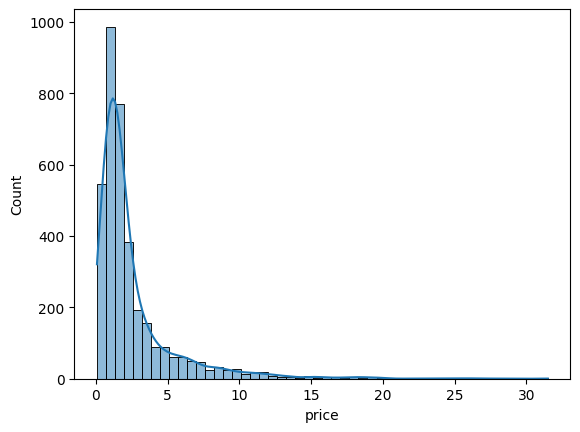

In [25]:
sns.histplot(df['price'], kde=True, bins=50)

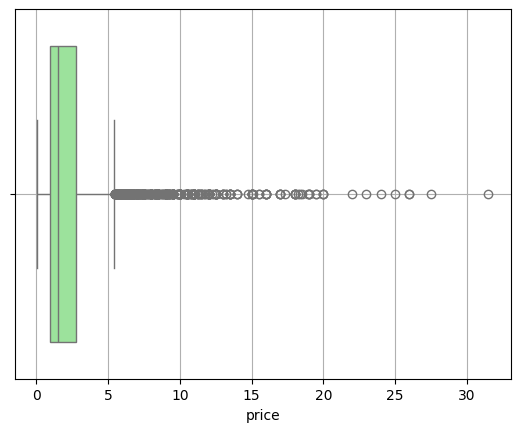

In [26]:
sns.boxplot(x=df['price'], color='lightgreen')
plt.grid()

## Observations

### Descriptive Statistics

- The **price** feature contains **3,660** non-missing observations, with **17 missing values** that should be handled during data preprocessing.
- The **average property price** is **2.53 crores**, whereas the **median price** is **1.52 crores**.
- The **mean is considerably higher than the median**, indicating that the price distribution is **positively (right) skewed**, primarily due to the presence of a few high-priced luxury properties.
- Property prices exhibit substantial variability, with a **standard deviation of 2.98 crores**.
- Prices range from **0.07 crores** to **31.50 crores**, highlighting a wide spread in the housing market.
- The **interquartile range (IQR)** spans from **0.95 crores (Q1)** to **2.75 crores (Q3)**, suggesting that the middle 50% of properties are priced within this interval.

### Distribution Analysis

- The histogram reveals that **most properties are concentrated in the lower price range (below 5 crores)**, while the frequency decreases as the price increases.
- The distribution exhibits a **long right tail**, confirming the presence of a small number of premium or luxury properties with exceptionally high prices.

### Outlier Analysis

- The box plot indicates the presence of **several upper-end outliers**, particularly for properties priced above **approximately 10 crores**.
- These high-value properties are likely genuine luxury listings rather than data entry errors and should be investigated further before deciding whether to retain, transform, or treat them separately during modeling.
```

In [27]:
# Skewness and Kurtosis
skewness = df['price'].skew()
kurtosis = df['price'].kurt()

print(skewness,kurtosis)

3.279170473313463 14.933372629214258


## Distribution Characteristics

- The **price** distribution has a **skewness of 3.28**, indicating a **strong positive (right) skew**.
- This implies that **most properties are concentrated in the lower price range**, while a relatively small number of premium properties with exceptionally high prices create a long right tail.
- The observed skewness is consistent with the histogram, where the majority of listings are below **5 crores**, with only a few high-value properties extending up to **31.5 crores**.
- The **kurtosis value of 14.93** is substantially higher than the kurtosis of a normal distribution (**3**), indicating a **leptokurtic distribution**.
- A high kurtosis suggests the presence of **heavy tails** and **more extreme values (outliers)** than would be expected under a normal distribution.
- The combination of **high positive skewness** and **high kurtosis** confirms that the **price** feature is **non-normally distributed** and contains several high-value outliers.
- Prior to model development, it would be beneficial to consider **log transformation** of the target variable (`price`) to reduce skewness, stabilize variance, and improve the performance of regression models.

In [28]:
# Quantile Analysis
quantiles = df['price'].quantile([0.01, 0.05, 0.95, 0.99])

quantiles

0.01     0.250
0.05     0.370
0.95     8.500
0.99    15.264
Name: price, dtype: float64

## Quantile Analysis

- The **1st percentile (0.25 crores)** indicates that only **1%** of properties are priced below **0.25 crores**, suggesting that extremely low-priced properties are rare in the dataset.
- The **5th percentile (0.37 crores)** shows that **95%** of the properties have prices **above 0.37 crores**, confirming that the majority of listings fall well above this price level.
- The **95th percentile (8.50 crores)** indicates that **95%** of properties are priced at or below **8.50 crores**, while only the top **5%** exceed this value.
- The **99th percentile (15.26 crores)** reveals that **99%** of properties are priced below **15.26 crores**, with only **1%** of listings exceeding this threshold.
- The large gap between the **95th percentile (8.50 crores)** and the **maximum price (31.50 crores)** highlights the presence of a small number of exceptionally expensive luxury properties.
- Overall, the quantile analysis reinforces the earlier findings that the **price distribution is highly right-skewed**, with most properties concentrated in the lower to mid-price range and only a few premium properties occupying the upper tail of the distribution.

In [29]:
# Identify potential outliers using IQR method
Q1 = df['price'].describe()['25%']
Q3 = df['price'].describe()['75%']
IQR = Q3 - Q1

IQR

np.float64(1.8)

In [30]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound, upper_bound)

-1.7500000000000002 5.45


In [31]:
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
outliers.shape

(425, 23)

In [32]:
outliers['price'].describe()

count    425.000000
mean       9.235624
std        4.065259
min        5.460000
25%        6.460000
50%        8.000000
75%       10.750000
max       31.500000
Name: price, dtype: float64

## Outlier Analysis (IQR Method)

- Using the **Interquartile Range (IQR) method**, **425 properties** are identified as potential outliers based on their price.
- These outlier properties have an **average price of approximately 9.24 crores**, which is substantially higher than the overall dataset mean of **2.53 crores**.
- The prices of these outliers range from **5.46 crores** to **31.50 crores**, representing the premium and luxury segment of the housing market.
- The presence of a relatively large number of upper-end outliers is consistent with the previously observed **high positive skewness (3.28)** and **high kurtosis (14.93)**, indicating a long right tail in the price distribution.
- Since these observations correspond to **genuinely expensive properties** rather than apparent data entry errors, they should **not be removed blindly**. Instead, they should be validated and handled appropriately using techniques such as **log transformation**, **robust regression models**, or **outlier-aware feature engineering**.
- Overall, the outlier analysis suggests that the dataset contains a distinct luxury property segment that may significantly influence statistical summaries and machine learning model performance if left untreated.

<Axes: xlabel='price'>

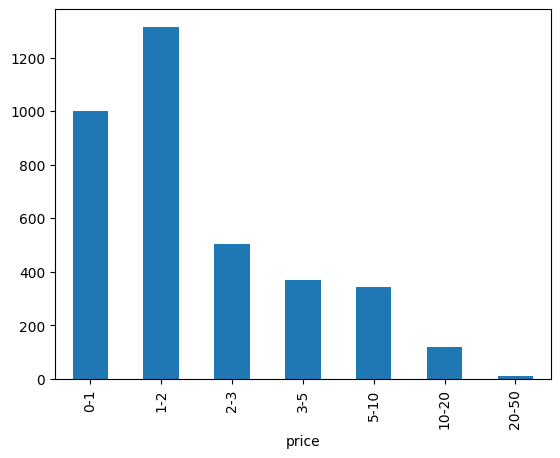

In [33]:
# price binning
bins = [0, 1, 2, 3, 5, 10, 20, 50]
bin_labels = ["0-1", "1-2", "2-3", "3-5", "5-10", "10-20", "20-50"]
pd.cut(df['price'], bins=bins, labels=bin_labels, right=False).value_counts().sort_index().plot(kind='bar')

## Observations

- The highest concentration of properties falls within the **1–2 crores** and **2–3 crores** price ranges, indicating that these segments represent the core of the residential market.
- The number of property listings decreases progressively as the price range increases, suggesting an inverse relationship between price and listing frequency.
- There is a **notable decline** in the number of properties priced **above 5 crores**, indicating that premium and luxury properties constitute only a small proportion of the dataset.
- Properties priced above **10 crores** are relatively rare, highlighting the limited presence of ultra-luxury listings.
- Overall, the binned price distribution further confirms that the housing market is **concentrated in the lower to mid-price segments**, while high-value properties form a relatively small but distinct luxury segment.

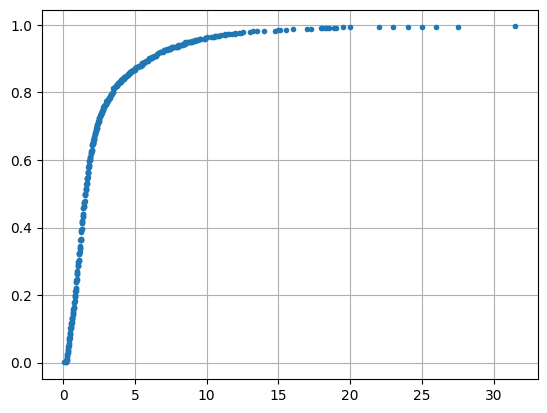

In [34]:
# ecdf plot
ecdf = df['price'].value_counts().sort_index().cumsum() / len(df['price'])
plt.plot(ecdf.index, ecdf, marker='.', linestyle='none')
plt.grid()

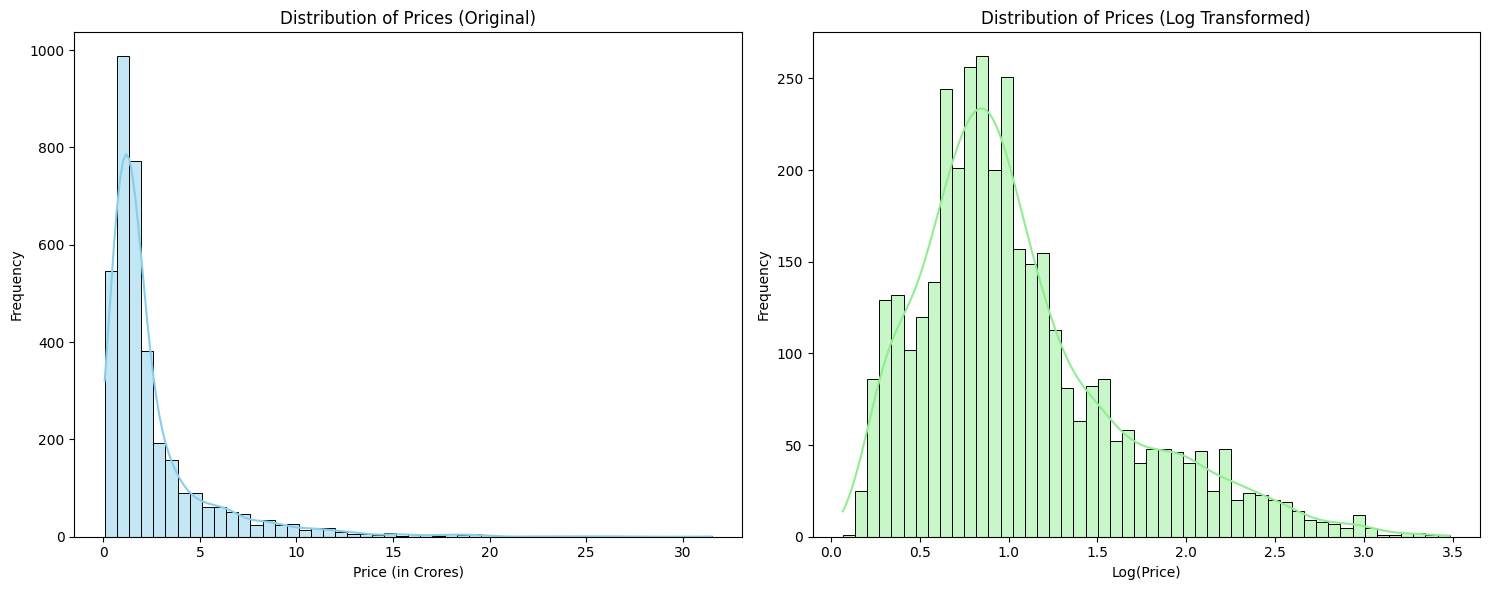

In [35]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.histplot(df['price'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['price']), kde=True, bins=50, color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## Log Transformation (`np.log1p`)

- The `np.log1p(x)` function computes the **natural logarithm of (1 + x)**, i.e., **ln(1 + x)**.
- Unlike `np.log(x)`, `np.log1p()` safely handles **zero values**, since `ln(1 + 0) = 0`, thereby avoiding undefined results.
- It is also **numerically more stable** for values of `x` that are very close to zero, making it preferable to computing `np.log(1 + x)` directly.
- Applying `np.log1p()` to the **price** feature compresses the range of large values, reducing the impact of extreme observations and mitigating the effect of positive skewness.
- As a result, the transformed distribution is typically **closer to a normal distribution**, which can improve the performance of many machine learning algorithms, particularly linear regression models.
- The transformation is **fully reversible** using `np.expm1(x)`, which computes **e<sup>x</sup> − 1**, allowing predictions made in the transformed space to be converted back to the original price scale.
- Since the **price** feature exhibits substantial positive skewness and several high-value outliers, applying a log transformation is an appropriate preprocessing step before model development.

In [36]:
skewness = np.log1p(df['price']).skew()
kurtosis = np.log1p(df['price']).kurt()

print(skewness,kurtosis)

1.0740709565255313 0.9646692415449274


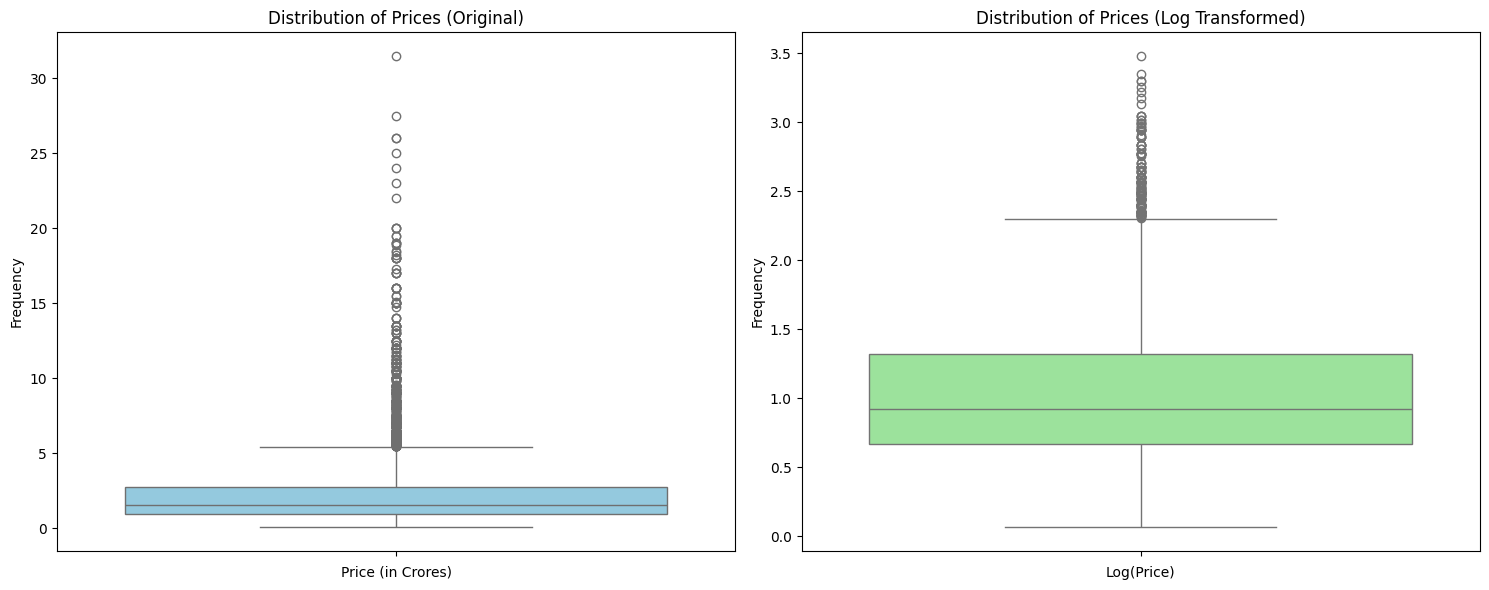

In [37]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.boxplot(df['price'], color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.boxplot(np.log1p(df['price']), color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### price_per_sqft

In [38]:
df['price_per_sqft'].isnull().sum()

np.int64(17)

In [39]:
df['price_per_sqft'].describe()

count      3660.000000
mean      13892.668306
std       23210.067190
min           4.000000
25%        6817.250000
50%        9020.000000
75%       13880.500000
max      600000.000000
Name: price_per_sqft, dtype: float64

<Axes: xlabel='price_per_sqft', ylabel='Count'>

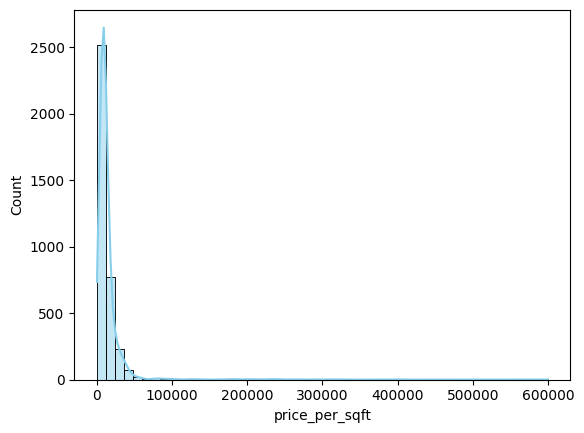

In [40]:
sns.histplot(df['price_per_sqft'], bins=50, color='skyblue', kde=True)

## Observations

- Most properties have a **price per square foot** ranging between **₹0 and ₹40,000**.
- The distribution is heavily concentrated in the lower price-per-square-foot range.
- A small number of properties have exceptionally high **price per square foot**, indicating the presence of potential outliers.
```

<Axes: ylabel='price_per_sqft'>

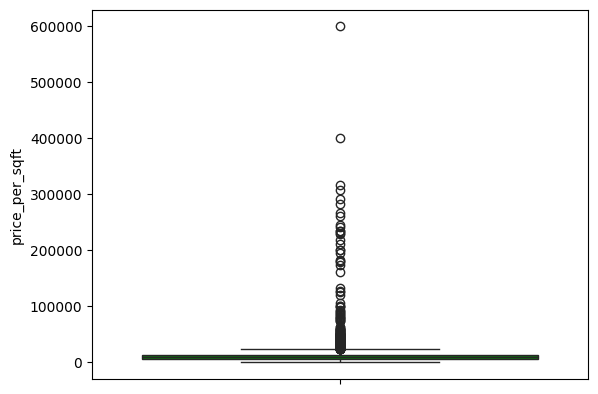

In [41]:
sns.boxplot(df['price_per_sqft'], color='green')

## Observations

- The box plot indicates the presence of **several potential outliers**, particularly on the higher end of the **price per square foot** distribution.
- The distribution is **positively (right) skewed**, with most properties concentrated in the lower range and a few properties having exceptionally high values.
- The **interquartile range (IQR)** is relatively compact, while numerous observations lie beyond the upper whisker, suggesting the presence of high-value outliers.
- The **price per square foot** feature contains **17 missing values**.

### bedRoom

In [42]:
df['bedRoom'].isnull().sum()

np.int64(0)

<Axes: xlabel='bedRoom'>

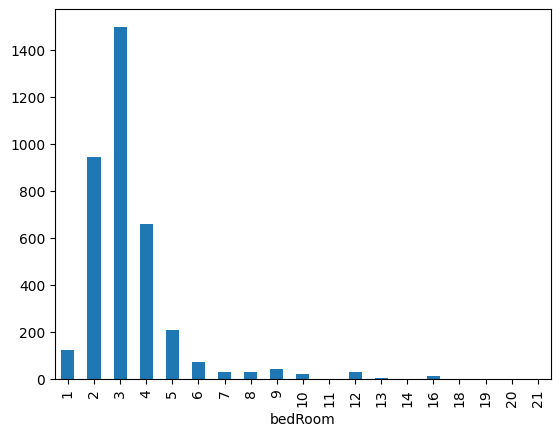

In [43]:
df['bedRoom'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='proportion'>

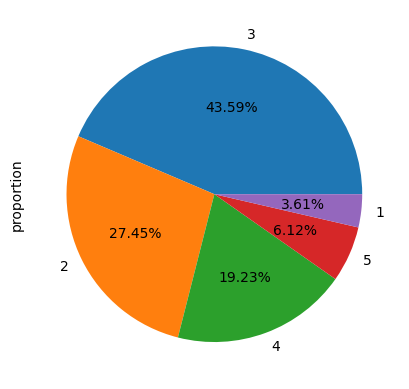

In [44]:
df['bedRoom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

### bathroom

In [45]:
df['bathroom'].isnull().sum()

np.int64(0)

<Axes: xlabel='bathroom'>

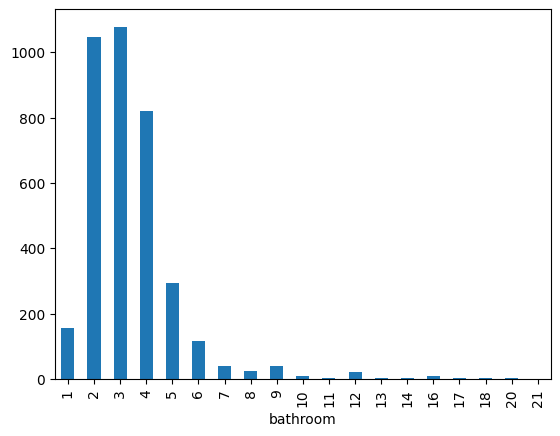

In [46]:
df['bathroom'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='proportion'>

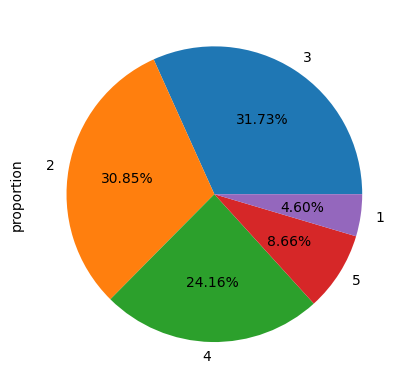

In [47]:
df['bathroom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

### balcony

In [48]:
df['balcony'].isnull().sum()

np.int64(0)

<Axes: xlabel='balcony'>

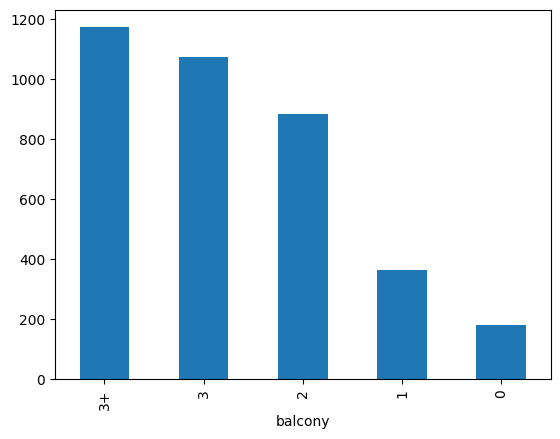

In [49]:
df['balcony'].value_counts().plot(kind='bar')

<Axes: ylabel='proportion'>

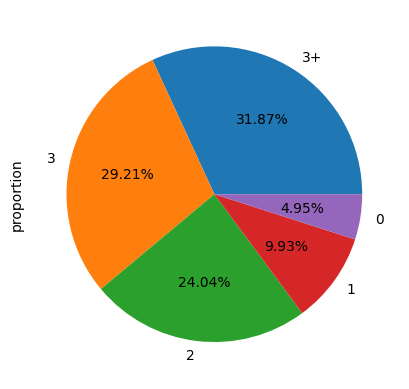

In [50]:
df['balcony'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

### floorNum

In [51]:
df.iloc[:,10:].head()

,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,4.0,NaN,Undefined,NaN,1743.0,NaN,0,0,0,0,0,0,0
1,16.0,NaN,New Property,2090.0,NaN,NaN,0,1,0,0,0,0,107
2,2.0,West,Old Property,NaN,7000.0,NaN,1,1,1,1,0,0,77
3,3.0,North,New Property,1727.0,NaN,1017.0,0,0,1,0,0,1,142
4,3.0,North-East,Moderately Old,NaN,206.0,205.0,0,0,1,0,0,1,80


In [52]:
df['floorNum'].isnull().sum()

np.int64(19)

In [53]:
df['floorNum'].describe()

count    3658.000000
mean        6.798250
std         6.012454
min         0.000000
25%         2.000000
50%         5.000000
75%        10.000000
max        51.000000
Name: floorNum, dtype: float64

<Axes: xlabel='floorNum'>

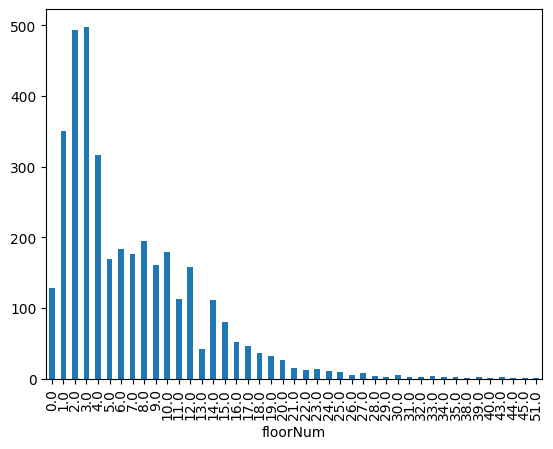

In [54]:
df['floorNum'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='floorNum'>

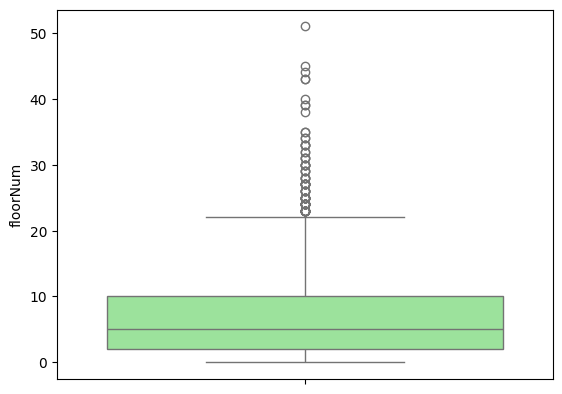

In [55]:
sns.boxplot(df['floorNum'], color='lightgreen')

## Observations

- The majority of properties are located between the **ground floor (0)** and the **25th floor**.
- **Floors 1 to 4** are the most common, with the **3rd floor** having the highest number of properties.
- The frequency of properties decreases as the floor level increases, with only a few properties located on higher floors.
- The box plot shows that the **middle 50%** of properties are concentrated between approximately the **2nd and 10th floors**, indicating that most listings are in low- to mid-rise buildings.
- Several observations lie beyond the upper whisker of the box plot, suggesting the presence of **potential high-floor outliers**.

### facing

In [56]:

df['facing'].isnull().sum()

np.int64(1045)

In [57]:
df['facing'].fillna('NA',inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_28312\3692945726.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['facing'].fillna('NA',inplace=True)


In [58]:
df['facing'].value_counts()

facing
NA            1045
North-East     623
East           623
North          387
West           249
South          231
North-West     193
South-East     173
South-West     153
Name: count, dtype: int64

### agePossession

In [59]:
df['agePossession'].isnull().sum()

np.int64(0)

In [60]:
df['agePossession'].value_counts()

agePossession
Relatively New        1646
New Property           593
Moderately Old         563
Undefined              306
Old Property           303
Under Construction     266
Name: count, dtype: int64

### areas

In [61]:
# super built up area
df['super_built_up_area'].isnull().sum()

np.int64(1802)

In [62]:
df['super_built_up_area'].describe()

count     1875.000000
mean      1925.237627
std        764.172177
min         89.000000
25%       1479.500000
50%       1828.000000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

<Axes: xlabel='super_built_up_area', ylabel='Count'>

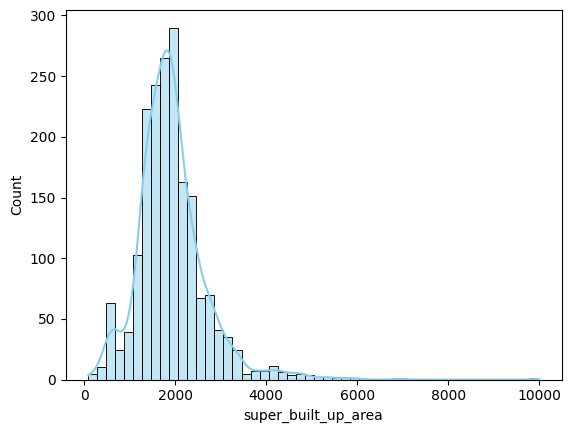

In [63]:
sns.histplot(df['super_built_up_area'].dropna(), bins=50, color='skyblue', kde=True)

<Axes: ylabel='super_built_up_area'>

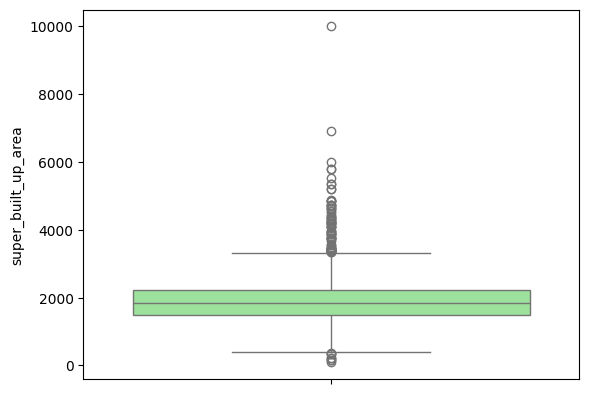

In [64]:
sns.boxplot(df['super_built_up_area'].dropna(), color='lightgreen')

## Observations

- Most properties have a **super built-up area** ranging between **1,000 sq.ft** and **2,500 sq.ft**.
- The distribution is **positively (right) skewed**, with a small number of properties having exceptionally large super built-up areas.
- The **interquartile range (IQR)** lies between approximately **1,480 sq.ft** and **2,215 sq.ft**, indicating that the middle **50%** of properties fall within this range.
- The box plot reveals several observations beyond the upper whisker, suggesting the presence of **potential outliers** corresponding to properties with unusually large super built-up areas.

In [65]:
# built up area
df['built_up_area'].isnull().sum()

np.int64(1987)

In [66]:
df['built_up_area'].describe()

count      1690.000000
mean       2379.585816
std       17942.880237
min           2.000000
25%        1100.000000
50%        1650.000000
75%        2400.000000
max      737147.000000
Name: built_up_area, dtype: float64

<Axes: xlabel='built_up_area', ylabel='Count'>

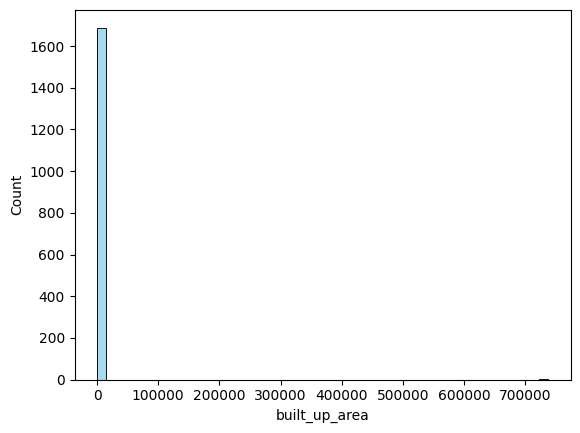

In [67]:
sns.histplot(df['built_up_area'].dropna(), bins=50, color='skyblue', kde=False)

<Axes: ylabel='built_up_area'>

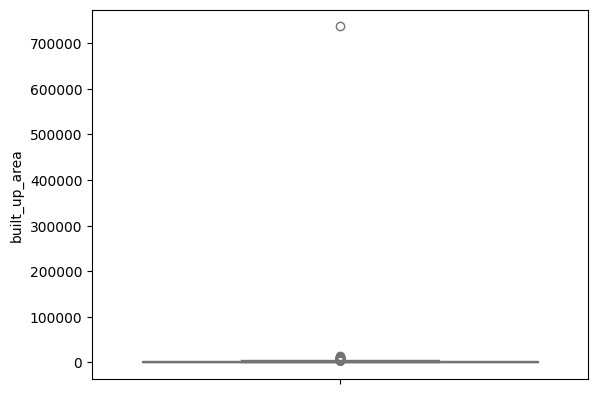

In [68]:
sns.boxplot(df['built_up_area'].dropna(), color='lightgreen')

## Observations

- Most properties have a **built-up area** ranging between **500 sq.ft** and **3,500 sq.ft**.
- The distribution is **highly positively (right) skewed**, with only a few properties having exceptionally large built-up areas.
- The **interquartile range (IQR)** is relatively compact, indicating that the majority of properties are clustered within a narrow range of built-up areas.
- The box plot reveals several observations beyond the upper whisker, indicating the presence of **significant high-end outliers**.
- These extreme values may represent **luxury properties, commercial buildings, or data inconsistencies**, and should be validated before further analysis or model development.

In [69]:
# carpet area
df['carpet_area'].isnull().sum()

np.int64(1805)

In [70]:
df['carpet_area'].describe()

count      1872.000000
mean       2529.179507
std       22799.836449
min          15.000000
25%         843.000000
50%        1300.000000
75%        1790.000000
max      607936.000000
Name: carpet_area, dtype: float64

<Axes: xlabel='carpet_area', ylabel='Count'>

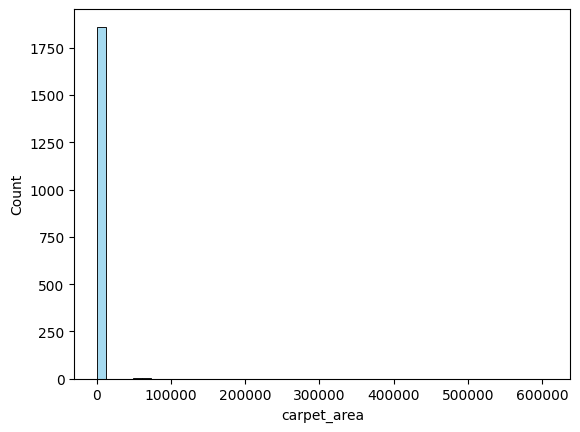

In [71]:
sns.histplot(df['carpet_area'].dropna(), bins=50, color='skyblue', kde=False)

<Axes: ylabel='carpet_area'>

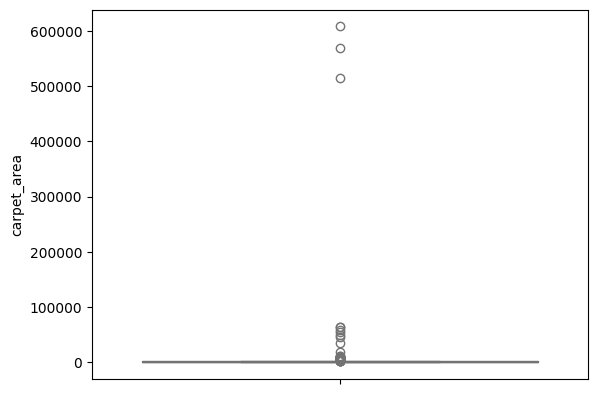

In [72]:
sns.boxplot(df['carpet_area'].dropna(), color='lightgreen')

In [73]:
df.iloc[:,16:]

,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,107
2,1,1,1,1,0,0,77
3,0,0,1,0,0,1,142
4,0,0,1,0,0,1,80
...,...,...,...,...,...,...,...
3798,0,1,0,0,0,1,110
3799,0,1,0,0,0,0,174
3800,0,0,0,0,0,0,85
3801,0,1,0,1,1,0,166


### additional rooms

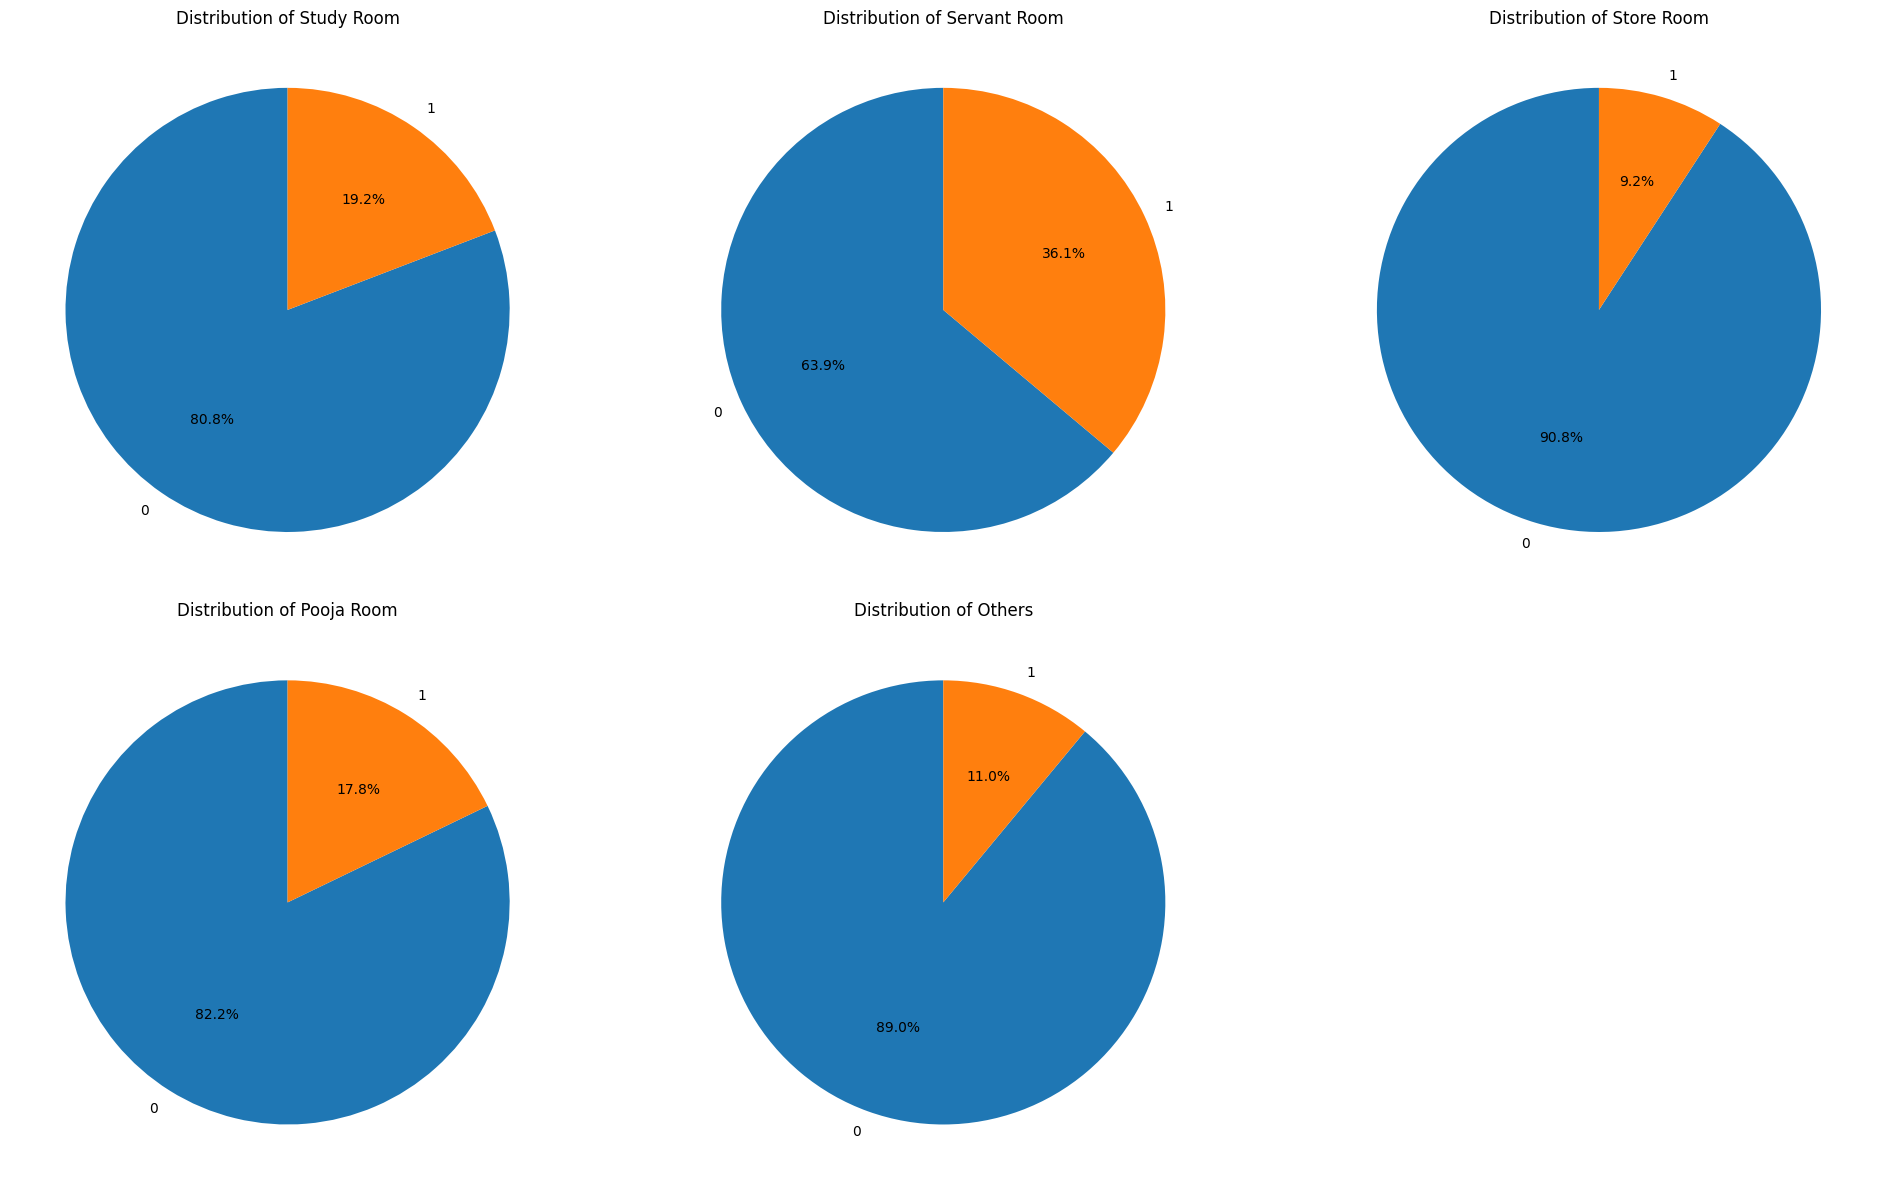

In [74]:
plt.figure(figsize=(20, 12))

# Create a subplot of pie charts for each room type
for idx, room in enumerate(['study room','servant room','store room','pooja room','others'], 1):
    ax = plt.subplot(2, 3, idx)
    df[room].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, ax=ax)
    plt.title(f'Distribution of {room.title()}')
    plt.ylabel('')

plt.tight_layout()
plt.show()

### furnishing_type

In [75]:
df['furnishing_type'].value_counts()

furnishing_type
0    2435
1    1038
2     204
Name: count, dtype: int64

<Axes: ylabel='count'>

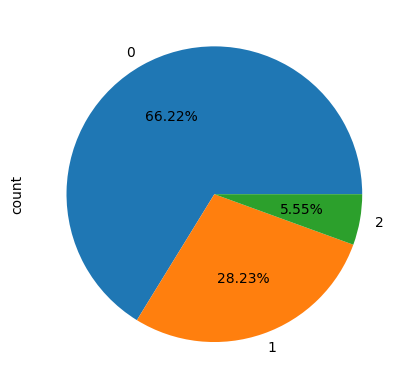

In [76]:
df['furnishing_type'].value_counts().plot(kind='pie',autopct='%0.2f%%')

### luxury score

In [77]:
df['luxury_score'].isnull().sum()

np.int64(0)

In [78]:
df['luxury_score'].describe()

count    3677.000000
mean       71.512918
std        53.059082
min         0.000000
25%        31.000000
50%        59.000000
75%       110.000000
max       174.000000
Name: luxury_score, dtype: float64

<Axes: xlabel='luxury_score', ylabel='Count'>

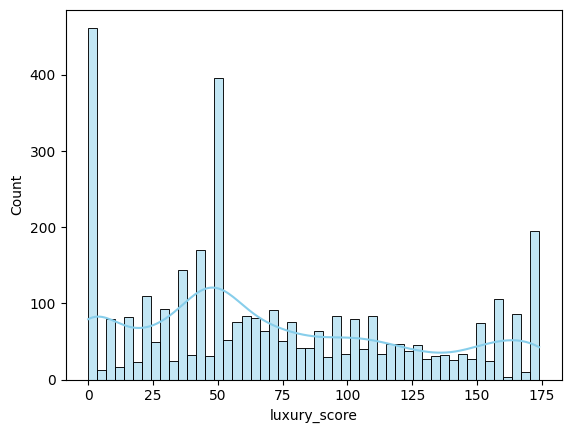

In [79]:
sns.histplot(df['luxury_score'], bins=50, color='skyblue', kde=True)

<Axes: ylabel='luxury_score'>

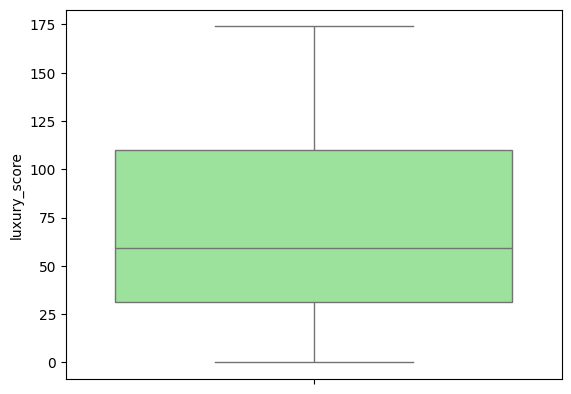

In [80]:
sns.boxplot(df['luxury_score'], color='lightgreen')

The luxury score distribution has multiple peaks, suggesting a multi-modal distribution. There's a significant number of properties with lower luxury scores (around 0-50), and another peak is observed around the 110-130 range.

The box plot reveals that the majority of the properties have luxury scores between approximately 30 and 110. The interquartile range (IQR) lies between these values.

In [81]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,sare crescent parc royal greens phase 1,sector 92,0.85,4877.0,1743.0,Built Up area: 1743 (161.93 sq.m.),4,4,3,...,NaN,1743.0,NaN,0,0,0,0,0,0,0
1,flat,sare green parc phase 3,sector 92,1.08,5150.0,2097.0,Super Built up area 2090(194.17 sq.m.),4,4,2,...,2090.0,NaN,NaN,0,1,0,0,0,0,107
2,house,unitech uniworld resorts,sector 33,8.00,11428.0,7000.0,Plot area 7000(650.32 sq.m.),4,4,3+,...,NaN,7000.0,NaN,1,1,1,1,0,0,77
3,flat,ireo the corridors,sector 67a,1.60,9264.0,1727.0,Super Built up area 1727(160.44 sq.m.)Carpet a...,3,3,2,...,1727.0,NaN,1017.0,0,0,1,0,0,1,142
4,house,rwa sector 46,sector 46,4.50,24390.0,1845.0,Plot area 204(170.57 sq.m.)Built Up area: 206 ...,6,6,3+,...,NaN,206.0,205.0,0,0,1,0,0,1,80
